In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('/content/StudentsPerformance.csv.xls')

print("Dataset loaded successfully!")
print(df.head())

Dataset loaded successfully!
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [8]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape: (1000, 8)

Columns:
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

Data Types:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object


In [9]:
print(df.isnull().sum())


cat_cols = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled!")

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64
Missing values handled!


In [10]:
for col in cat_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

print(df[cat_cols].head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group b           bachelor's degree      standard   
1  female        group c                some college      standard   
2  female        group b             master's degree      standard   
3    male        group a          associate's degree  free/reduced   
4    male        group c                some college      standard   

  test preparation course  
0                    none  
1               completed  
2                    none  
3                    none  
4                    none  


In [11]:
for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts())


 gender
gender
female    518
male      482
Name: count, dtype: int64

 race/ethnicity
race/ethnicity
group c    319
group d    262
group b    190
group e    140
group a     89
Name: count, dtype: int64

 parental level of education
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

 lunch
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

 test preparation course
test preparation course
none         642
completed    358
Name: count, dtype: int64


In [12]:
score_cols = [
    'math score',
    'reading score',
    'writing score'
]

In [13]:
quartiles = df[score_cols].quantile([0.25, 0.50, 0.75])

print(quartiles)

      math score  reading score  writing score
0.25        57.0           59.0          57.75
0.50        66.0           70.0          69.00
0.75        77.0           79.0          79.00


In [14]:
df['total marks'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
)

print(df[['math score', 'reading score', 'writing score', 'total marks']].head())

   math score  reading score  writing score  total marks
0          72             72             74          218
1          69             90             88          247
2          90             95             93          278
3          47             57             44          148
4          76             78             75          229


In [15]:
df['percentage'] = (df['total marks'] / 300) * 100

print(df[['total marks', 'percentage']].head())

   total marks  percentage
0          218   72.666667
1          247   82.333333
2          278   92.666667
3          148   49.333333
4          229   76.333333


In [16]:
df['percentage'] = df['percentage'].round(2)

print(df[['total marks', 'percentage']].head())

   total marks  percentage
0          218       72.67
1          247       82.33
2          278       92.67
3          148       49.33
4          229       76.33


In [17]:
def find_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    return outliers, lower, upper

In [18]:
math_outliers, lower, upper = find_outliers('math score')

print("Math Score")
print("Lower Limit:", lower)
print("Upper Limit:", upper)
print("Number of Outliers:", len(math_outliers))

Math Score
Lower Limit: 27.0
Upper Limit: 107.0
Number of Outliers: 8


In [19]:
reading_outliers, lower, upper = find_outliers('reading score')

print("Reading Score")
print("Lower Limit:", lower)
print("Upper Limit:", upper)
print("Number of Outliers:", len(reading_outliers))

Reading Score
Lower Limit: 29.0
Upper Limit: 109.0
Number of Outliers: 6


In [20]:
writing_outliers, lower, upper = find_outliers('writing score')

print("Writing Score")
print("Lower Limit:", lower)
print("Upper Limit:", upper)
print("Number of Outliers:", len(writing_outliers))

Writing Score
Lower Limit: 25.875
Upper Limit: 110.875
Number of Outliers: 5


In [21]:
df['outlier'] = False

for col in score_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df['outlier'] = df['outlier'] | (
        (df[col] < lower) | (df[col] > upper)
    )

print(df['outlier'].value_counts())

outlier
False    988
True      12
Name: count, dtype: int64


In [22]:
outlier_students = df[df['outlier'] == True]

print(outlier_students[
    ['gender',
     'race/ethnicity',
     'math score',
     'reading score',
     'writing score',
     'total marks',
     'percentage']
])

     gender race/ethnicity  math score  reading score  writing score  \
17   female        group b          18             32             28   
59   female        group c           0             17             10   
76     male        group e          30             26             22   
145  female        group c          22             39             33   
211    male        group c          35             28             27   
327    male        group a          28             23             19   
338  female        group b          24             38             27   
466  female        group d          26             31             38   
596    male        group b          30             24             15   
787  female        group b          19             38             32   
842  female        group b          23             44             36   
980  female        group b           8             24             23   

     total marks  percentage  
17            78       26.00  
5

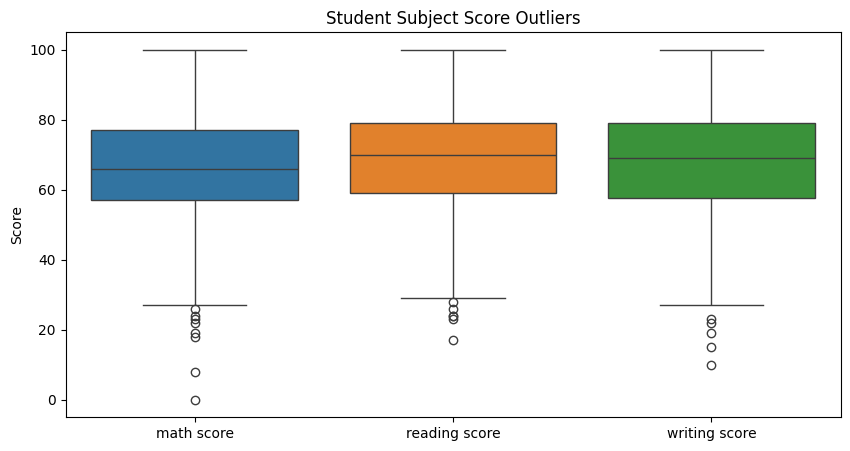

In [23]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df[score_cols])

plt.title("Student Subject Score Outliers")
plt.ylabel("Score")
plt.show()

In [24]:
print(df.head())
print("\nFinal Shape:", df.shape)

   gender race/ethnicity parental level of education         lunch  \
0  female        group b           bachelor's degree      standard   
1  female        group c                some college      standard   
2  female        group b             master's degree      standard   
3    male        group a          associate's degree  free/reduced   
4    male        group c                some college      standard   

  test preparation course  math score  reading score  writing score  \
0                    none          72             72             74   
1               completed          69             90             88   
2                    none          90             95             93   
3                    none          47             57             44   
4                    none          76             78             75   

   total marks  percentage  outlier  
0          218       72.67    False  
1          247       82.33    False  
2          278       92.67    False  


In [25]:
df.to_csv('StudentsPerformance_cleaned.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
